# per batch for experts

Classes after merge: 45 (was 50)
num_classes=45, input_dim=88, device=cuda

Final Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      6366
           1       0.79      0.98      0.87      6368
           2       1.00      1.00      1.00      6370
           3       0.96      0.98      0.97      6369
           4       0.87      0.65      0.74      6362
           5       1.00      1.00      1.00      6370
           6       1.00      1.00      1.00      6370
           7       1.00      1.00      1.00      6369
           8       1.00      0.93      0.96      6362
           9       1.00      1.00      1.00      6371
          10       1.00      1.00      1.00      6370
          11       1.00      0.99      0.99      6369
          12       1.00      0.99      1.00      6371
          13       1.00      1.00      1.00      6370
          14       1.00      1.00      1.00      6369
          15       1.00      

ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)

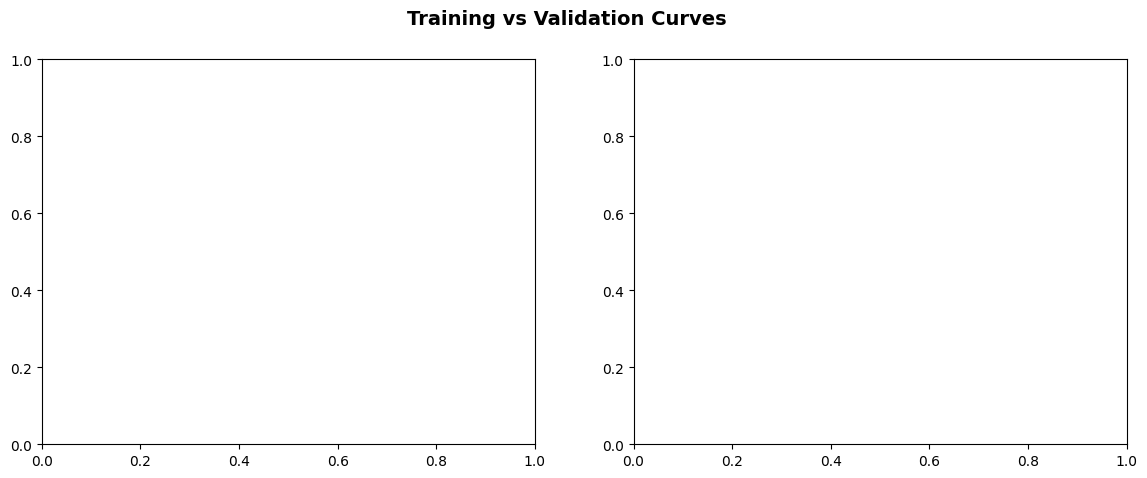

In [ ]:
import joblib
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

# =========================
# 1. Dataset class
# =========================
class NumericDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# =========================
# 2. Model Architectures
# =========================
class RoutingNet(nn.Module):
    def __init__(self, input_dim, num_experts):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.LayerNorm(256),   
            nn.ReLU(),
            nn.Linear(256, num_experts)
        )

    def forward(self, x):
        return self.sequential(x)

class Expert(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.LayerNorm(16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.classifier = nn.Sequential(
            nn.Linear(8, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.01),
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
       
    def forward(self, x):
        x = self.encoder(x)
        return self.classifier(x)

# =========================
# 3. Loss Functions
# =========================
def policy_gradient_loss(log_probs, reward):
    return -torch.mean(log_probs * reward)

def diversity_penalty(probs, num_experts):
    entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()
    max_entropy = torch.log(torch.tensor(float(num_experts)))
    return 1.0 - (entropy / (max_entropy + 1e-8))

def compute_router_loss(log_probs, reward, probs, num_experts, diversity_weight=0.1):  # updated
    pg_loss = policy_gradient_loss(log_probs, reward)
    div_penalty = diversity_penalty(probs, num_experts)
    return pg_loss + (diversity_weight * div_penalty)

def specialization_loss(latent_vectors, temperature=1.0):
    if len(latent_vectors) < 2:
        return torch.tensor(0.0, device=latent_vectors[0].device)

    pooled = torch.stack([v.mean(dim=0) for v in latent_vectors])
    pooled = nn.functional.normalize(pooled, p=2, dim=1)
    sim_matrix = torch.mm(pooled, pooled.T)

    n = sim_matrix.size(0)
    mask = torch.triu(torch.ones(n, n, device=pooled.device), diagonal=1).bool()
    pairwise_sims = sim_matrix[mask]

    loss = ((pairwise_sims + 1) / 2).mean()
    return loss / temperature

# =========================
# 4. Initialization & Data
# =========================
x_res = joblib.load('X_res.pkl')
y_res = joblib.load('y_res.pkl')

merge_map = {
    23: 22,
    27: 22,
    46: 43,
    49: 47,
    31: 30,
}
y_res = y_res.replace(merge_map)

unique_classes = sorted(y_res.unique())
remap = {old: new for new, old in enumerate(unique_classes)}
y_res = y_res.map(remap)

print(f"Classes after merge: {y_res.nunique()} (was 50)")

x_res, _, y_res, _ = train_test_split(
    x_res, y_res,
    train_size=0.99,
    stratify=y_res,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    x_res, y_res,
    test_size=0.2,
    stratify=y_res,
    random_state=42
)

num_classes = y_train.nunique()
input_dim   = X_train.shape[1]
device      = "cuda" if torch.cuda.is_available() else "cpu"

# ── Best hyperparameters ──────────────────────────────────────────
batch_size   = 256
n_epochs     = 10
n_experts    = 10
lr_router    = 0.005
lr_expert    = 0.001
K            = 5
spec_temp    = 1.0
spec_weight  = 0.1
div_weight   = 0.1
momentum     = 0.95
# ─────────────────────────────────────────────────────────────────
quant_ok     = False
if quant_ok:
    device = "cpu"
print(f"num_classes={num_classes}, input_dim={input_dim}, device={device}")

train_loader = DataLoader(NumericDataset(X_train, y_train), batch_size=batch_size, shuffle=True,  drop_last=True)
val_loader   = DataLoader(NumericDataset(X_val,   y_val),   batch_size=64,         shuffle=False, drop_last=False)

Router_model = RoutingNet(input_dim, n_experts).to(device)
experts      = [Expert(input_dim, num_classes).to(device) for _ in range(n_experts)]
#quanrization and pruning
import torch.nn.utils.prune as prune

prune_amount = 0.1

if quant_ok:
    checkpoint = torch.load("models/best_model.pth")
    Router_model.load_state_dict(checkpoint['router'])
    for i, e in enumerate(experts):
        e.load_state_dict(checkpoint['experts'][i])

    parameters_to_prune = (
        [(module, 'weight') for _, module in Router_model.named_modules() if isinstance(module, nn.Linear)] +
        [(module, 'weight') for e in experts for _, module in e.named_modules() if isinstance(module, nn.Linear)]
    )
    prune.global_unstructured(parameters_to_prune, pruning_method=prune.L1Unstructured, amount=prune_amount)

    # bake masks into weights before quantizing
    for module, _ in parameters_to_prune:
        prune.remove(module, 'weight')

    Router_model = torch.quantization.quantize_dynamic(Router_model, {nn.Linear}, dtype=torch.qint8)
    experts      = [torch.quantization.quantize_dynamic(e, {nn.Linear}, dtype=torch.qint8) for e in experts]

criterion_experts = nn.CrossEntropyLoss()
optimizer_router  = torch.optim.Adam(Router_model.parameters(), lr=lr_router)
optimizer_experts = [torch.optim.Adam(e.parameters(), lr=lr_expert) for e in experts]

# =========================
# 5. Training Loop
# =========================
checkpoint_path  = "best_model.pth"
final_model_path = "final_model.pth"
best_val_loss    = np.inf
reward_baseline  = 0.0

history = {
    "train_expert_loss": [],
    "val_expert_loss":   [],
    "train_router_acc":  [],
    "val_router_acc":    [],
}

for epoch in range(n_epochs):
    Router_model.train()
    for e in experts: e.train()

    epoch_expert_losses  = []
    epoch_router_correct = 0
    epoch_router_total   = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")

    for X_batch, y_batch in train_bar:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_router.zero_grad()

        logits = Router_model(X_batch)
        probs  = torch.softmax(logits, dim=1)
        X_batch.detach_()

        top_k_indices     = torch.topk(probs, k=K, dim=1).indices
        active_expert_ids = torch.unique(top_k_indices).tolist()

        for idx in active_expert_ids:
            optimizer_experts[idx].zero_grad()

        batch_preds    = []
        latent_vectors = []

        for idx in active_expert_ids:
            latent = experts[idx].encoder(X_batch)
            pred   = experts[idx].classifier(latent)
            batch_preds.append(pred)
            latent_vectors.append(latent.detach())

        spec_loss   = specialization_loss(latent_vectors, temperature=spec_temp)
        loss_expert = sum(criterion_experts(p, y_batch) for p in batch_preds) / len(batch_preds)
        loss_expert = loss_expert + spec_weight * spec_loss

        loss_expert.backward(retain_graph=True)

        with torch.no_grad():
            stacked      = torch.stack([p.argmax(1) for p in batch_preds])
            majority_vote = torch.mode(stacked, dim=0).values
            reward        = (majority_vote == y_batch).float()
            reward_baseline = momentum * reward_baseline + (1 - momentum) * reward.mean().item()
            reward        = reward - reward_baseline

        expert_mask = torch.zeros(X_batch.size(0), n_experts, device=device)
        expert_mask.scatter_(1, top_k_indices, 1.0)
        load_balance_loss = 10 * (probs.mean(0) * expert_mask.mean(0)).sum()

        chosen_log_probs = torch.log(probs.gather(1, top_k_indices) + 1e-8)
        loss_router = compute_router_loss(
            chosen_log_probs,
            reward.unsqueeze(1),
            probs,
            num_experts=n_experts,
            diversity_weight=div_weight,
        ) + 0.001 * load_balance_loss
        loss_router.backward()

        optimizer_router.step()
        for idx in active_expert_ids:
            optimizer_experts[idx].step()

        with torch.no_grad():
            router_accuracy = (majority_vote == y_batch).float().mean().item()

        train_bar.set_postfix(
            exp_loss=loss_expert.item(),
            spec_loss=f"{spec_loss.item():.4f}",
            router_acc=f"{router_accuracy:.2f}",
            router_loss=loss_router.item(),
            exp_used=len(active_expert_ids)
        )

        epoch_expert_losses.append(loss_expert.item())
        epoch_router_correct += (majority_vote == y_batch).sum().item()
        epoch_router_total   += y_batch.size(0)

    history["train_expert_loss"].append(np.mean(epoch_expert_losses))
    history["train_router_acc"].append(epoch_router_correct / epoch_router_total)

    # =========================
    # Validation
    # =========================
    Router_model.eval()
    for e in experts: e.eval()

    total_correct      = 0
    total_samples      = 0
    v_losses           = []
    val_router_correct = 0
    val_router_total   = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits          = Router_model(X_batch)
            top1_expert_idx = torch.argmax(logits, dim=1)

            expert_outputs = torch.stack([e(X_batch) for e in experts])
            chosen_preds   = expert_outputs.permute(1, 0, 2)[range(X_batch.size(0)), top1_expert_idx]

            batch_loss = criterion_experts(chosen_preds, y_batch)
            v_losses.append(batch_loss.item())

            preds = torch.argmax(chosen_preds, dim=1)
            total_correct      += (preds == y_batch).sum().item()
            total_samples      += y_batch.size(0)
            val_router_correct += (preds == y_batch).sum().item()
            val_router_total   += y_batch.size(0)

    val_loss = np.mean(v_losses)
    val_acc  = total_correct / total_samples
    print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f} | Router Top-1 Acc: {val_acc:.4f}")

    history["val_expert_loss"].append(val_loss)
    history["val_router_acc"].append(val_router_correct / val_router_total)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        if quant_ok==False:
            torch.save({
                'router':  Router_model.state_dict(),
                'experts': [e.state_dict() for e in experts],
            }, checkpoint_path)
            print(f"  ✓ Best model saved (val_loss={val_loss:.4f})")
        else:
            print(f"  ✓ Best model NOT saved due to quantization (val_loss={val_loss:.4f})")

# Save the final epoch weights regardless of whether it was the best
if quant_ok==False:
    torch.save({
        'router':  Router_model.state_dict(),
        'experts': [e.state_dict() for e in experts],
    }, final_model_path)
    print(f"Final model saved to {final_model_path}")

# =========================
# 6. Final Eval
# =========================
# if quant_ok==False:
#     checkpoint = torch.load("models/final_model.pth")
#     Router_model.load_state_dict(checkpoint['router'])
#     for i, e in enumerate(experts):
#         e.load_state_dict(checkpoint['experts'][i])

Router_model.eval()
for e in experts: e.eval()

all_preds, all_labels = [], []
skibiddie=0
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        router_logits = Router_model(X_batch)
        router_probs  = torch.softmax(router_logits, dim=1)
        if skibiddie == 1:#test multiple experts during inference instead of 1 k=5
            top_k_indices     = torch.topk(router_probs, k=K, dim=1).indices
            active_expert_ids = torch.unique(top_k_indices).tolist()
            batch_preds = []
            for idx in active_expert_ids:
                latent = experts[idx].encoder(X_batch)
                pred   = experts[idx].classifier(latent)
                batch_preds.append(pred)
            stacked       = torch.stack([p.argmax(1) for p in batch_preds])
            final_preds   = torch.mode(stacked, dim=0).values
        else:
            expert_outputs = torch.stack([torch.softmax(e(X_batch), dim=1) for e in experts])
            combined       = (router_probs.unsqueeze(2) * expert_outputs.permute(1, 0, 2)).sum(dim=1)
            final_preds    = torch.argmax(combined, dim=1)

        # ✅ Always collected, regardless of branch
        all_preds.extend(final_preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print("\nFinal Classification Report:\n", classification_report(all_labels, all_preds))

# =========================
# 7. Plot Training Curves
# =========================
epochs_range = range(1, n_epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training vs Validation Curves", fontsize=14, fontweight="bold")

ax1.plot(epochs_range, history["train_expert_loss"], marker="o", label="Train Expert Loss", color="steelblue")
ax1.plot(epochs_range, history["val_expert_loss"],   marker="o", label="Val Expert Loss",   color="tomato")
ax1.set_title("Expert Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.plot(epochs_range, history["train_router_acc"], marker="o", label="Train Router Acc", color="steelblue")
ax2.plot(epochs_range, history["val_router_acc"],   marker="o", label="Val Router Acc",   color="tomato")
ax2.set_title("Router Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to training_curves.png")

# per sample on experts


Classes after merge: 45 (was 50)
num_classes=45, input_dim=88, device=cuda


Epoch 1/10:   3%|▎         | 17/501 [01:27<41:39,  5.16s/it, exp_loss=3.56, exp_used=3, router_acc=0.09, router_loss=0.0898, spec_loss=0.6140]


KeyboardInterrupt: 

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1650


# GRID SEARCH

Classes after merge: 45 (was 50)
Grid search train size: 3852 | val size: 964
num_classes=45, input_dim=88, device=cuda
Total configs to evaluate: 3645


Grid Search: 100%|██████████| 3645/3645 [2:55:43<00:00,  2.89s/it, Best F1=0.5382, Last Gap=0.5026]  



WINNER CONFIG: {
  "batch_size": 256,
  "n_epochs": 5,
  "n_experts": 30,
  "lr_router": 0.005,
  "lr_expert": 0.001,
  "K": 5,
  "spec_temp": 1.0,
  "spec_weight": 0.1,
  "div_weight": 0.1,
  "momentum": 0.95
}
Running final evaluation on winner...


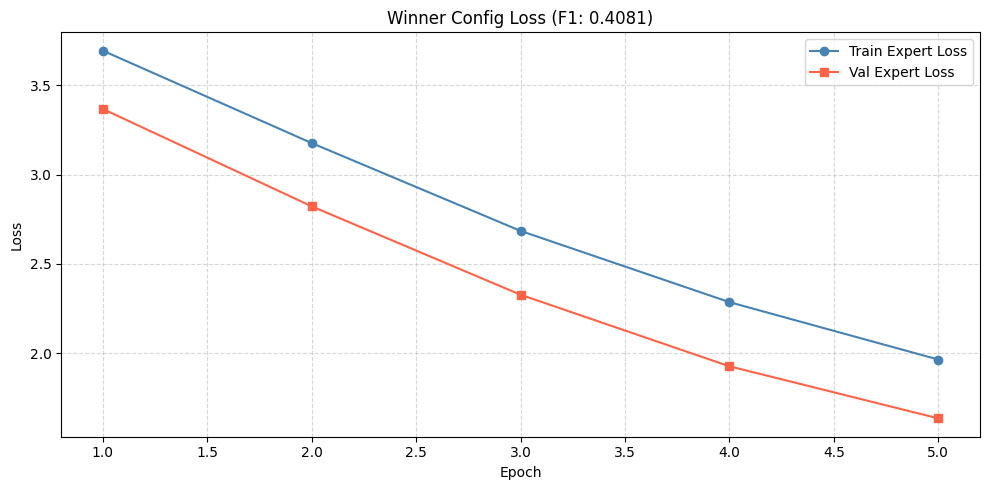


Final Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.00      0.00      0.00        19
           2       0.78      0.90      0.84        20
           3       0.82      0.74      0.78        19
           4       0.29      0.11      0.15        19
           5       0.49      1.00      0.66        19
           6       1.00      1.00      1.00        20
           7       0.51      1.00      0.68        19
           8       0.00      0.00      0.00        19
           9       0.67      0.30      0.41        20
          10       1.00      0.95      0.97        19
          11       1.00      0.05      0.10        19
          12       0.00      0.00      0.00        20
          13       0.58      0.95      0.72        20
          14       0.50      0.95      0.65        19
          15       0.33      1.00      0.50        19
          16       1.00      0.68      0.81       

In [1]:
import joblib
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import itertools
from tqdm import tqdm

# =========================
# 1. Dataset class
# =========================
class NumericDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# =========================
# 2. Model Architectures (FIXED — exact same as main training script)
# =========================
class RoutingNet(nn.Module):
    def __init__(self, input_dim, num_experts):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LayerNorm(256),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, num_experts)
        )
    def forward(self, x): return self.sequential(x)

class Expert(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.LayerNorm(16),
            nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.classifier = nn.Sequential(
            nn.Linear(8, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.01),
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.encoder(x)
        return self.classifier(x)

# =========================
# 3. Loss Functions (FIXED)
# =========================
def policy_gradient_loss(log_probs, reward):
    return -torch.mean(log_probs * reward)

def diversity_penalty(probs, num_experts):
    entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1).mean()
    max_entropy = torch.log(torch.tensor(float(num_experts)))
    return 1.0 - (entropy / (max_entropy + 1e-8))

def compute_router_loss(log_probs, reward, probs, num_experts, diversity_weight):
    pg_loss = policy_gradient_loss(log_probs, reward)
    div_penalty = diversity_penalty(probs, num_experts)
    return pg_loss + (diversity_weight * div_penalty)

def specialization_loss(latent_vectors, temperature):
    if len(latent_vectors) < 2:
        return torch.tensor(0.0, device=latent_vectors[0].device)
    pooled = torch.stack([v.mean(dim=0) for v in latent_vectors])
    pooled = nn.functional.normalize(pooled, p=2, dim=1)
    sim_matrix = torch.mm(pooled, pooled.T)
    n = sim_matrix.size(0)
    mask = torch.triu(torch.ones(n, n, device=pooled.device), diagonal=1).bool()
    pairwise_sims = sim_matrix[mask]
    loss = ((pairwise_sims + 1) / 2).mean()
    return loss / temperature

# =========================
# 4. Data Setup
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"

x_res = joblib.load('X_res.pkl')
y_res = joblib.load('y_res.pkl')

merge_map = {
    23: 22,
    27: 22,
    46: 43,
    49: 47,
    31: 30,
}
y_res = y_res.replace(merge_map)

unique_classes = sorted(y_res.unique())
remap = {old: new for new, old in enumerate(unique_classes)}
y_res = y_res.map(remap)

print(f"Classes after merge: {y_res.nunique()} (was 50)")

# Small sample for grid search
x_small, _, y_small, _ = train_test_split(
    x_res, y_res,
    train_size=0.003,       # 1% of data — fast enough for grid search
    stratify=y_res,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    x_small, y_small,
    test_size=0.2,
    stratify=y_small,
    random_state=42
)

input_dim  = X_train.shape[1]
num_classes = y_train.nunique()
train_ds   = NumericDataset(X_train, y_train)
val_ds     = NumericDataset(X_val,   y_val)

print(f"Grid search train size: {len(train_ds)} | val size: {len(val_ds)}")
print(f"num_classes={num_classes}, input_dim={input_dim}, device={device}")

# =========================
# 5. Experiment Runner
# =========================
def run_experiment(config, return_history=False):
    N_EXPERTS = config['n_experts']

    t_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True,  drop_last=True)
    v_loader = DataLoader(val_ds,   batch_size=config['batch_size'], shuffle=False, drop_last=False)

    router  = RoutingNet(input_dim, N_EXPERTS).to(device)
    experts = [Expert(input_dim, num_classes).to(device) for _ in range(N_EXPERTS)]

    opt_router  = torch.optim.Adam(router.parameters(),       lr=config['lr_router'])
    opt_experts = [torch.optim.Adam(e.parameters(), lr=config['lr_expert']) for e in experts]
    criterion   = nn.CrossEntropyLoss()

    K                = config['K']
    reward_baseline  = 0.0
    history          = {'t_loss': [], 'v_loss': []}

    for epoch in range(config['n_epochs']):
        router.train()
        for e in experts: e.train()

        t_losses = []

        for X_b, y_b in t_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)

            opt_router.zero_grad()
            logits = router(X_b)
            probs  = torch.softmax(logits, dim=1)
            X_b.detach_()

            top_k_indices    = torch.topk(probs, k=K, dim=1).indices
            active_expert_ids = torch.unique(top_k_indices).tolist()

            for idx in active_expert_ids:
                opt_experts[idx].zero_grad()

            batch_preds    = []
            latent_vectors = []

            for idx in active_expert_ids:
                latent = experts[idx].encoder(X_b)
                pred   = experts[idx].classifier(latent)
                batch_preds.append(pred)
                latent_vectors.append(latent.detach())

            spec_loss   = specialization_loss(latent_vectors, temperature=config['spec_temp'])
            loss_expert = sum(criterion(p, y_b) for p in batch_preds) / len(batch_preds)
            loss_expert = loss_expert + config['spec_weight'] * spec_loss
            loss_expert.backward(retain_graph=True)

            with torch.no_grad():
                stacked       = torch.stack([p.argmax(1) for p in batch_preds])
                majority_vote = torch.mode(stacked, dim=0).values
                reward        = (majority_vote == y_b).float()
                reward_baseline = config['momentum'] * reward_baseline + (1 - config['momentum']) * reward.mean().item()
                reward        = reward - reward_baseline

            expert_mask = torch.zeros(X_b.size(0), N_EXPERTS, device=device)
            expert_mask.scatter_(1, top_k_indices, 1.0)
            load_balance_loss = 10 * (probs.mean(0) * expert_mask.mean(0)).sum()

            chosen_log_probs = torch.log(probs.gather(1, top_k_indices) + 1e-8)
            loss_router = compute_router_loss(
                chosen_log_probs,
                reward.unsqueeze(1),
                probs,
                num_experts=N_EXPERTS,
                diversity_weight=config['div_weight'],
            ) + 0.001 * load_balance_loss
            loss_router.backward()

            opt_router.step()
            for idx in active_expert_ids:
                opt_experts[idx].step()

            t_losses.append(loss_expert.item())

        # --- Validation ---
        router.eval()
        for e in experts: e.eval()

        v_losses, v_preds, v_true = [], [], []
        with torch.no_grad():
            for X_v, y_v in v_loader:
                X_v, y_v = X_v.to(device), y_v.to(device)
                top1     = torch.argmax(router(X_v), dim=1)
                outputs  = torch.stack([e(X_v) for e in experts]).permute(1, 0, 2)
                chosen   = outputs[range(X_v.size(0)), top1]
                v_losses.append(criterion(chosen, y_v).item())
                v_preds.extend(chosen.argmax(1).cpu().numpy())
                v_true.extend(y_v.cpu().numpy())

        history['t_loss'].append(np.mean(t_losses))
        history['v_loss'].append(np.mean(v_losses))

    f1 = f1_score(v_true, v_preds, average='weighted', zero_division=0)

    if return_history:
        return f1, history, v_true, v_preds
    return f1, history['t_loss'][-1], history['v_loss'][-1]

# =========================
# 6. Parameter Grid  (architecture is FIXED above — only these tune)
# =========================
param_grid = {
    'batch_size':   [ 256],
    'n_epochs':     [5],           # kept small for grid; bump up for final run
    'n_experts':    [10, 20, 30,50,70],
    'lr_router':    [5e-3, 1e-3, 5e-4],
    'lr_expert':    [5e-3, 1e-3, 5e-4],
    'K':            [2, 3, 5],
    'spec_temp':    [0.5, 1.0, 1.5],
    'spec_weight':  [0.05, 0.1, 0.3],
    'div_weight':   [0.1, 0.2, 0.4],
    'momentum':     [0.95],
}

keys, values = zip(*param_grid.items())
configs = [dict(zip(keys, v)) for v in itertools.product(*values)]
print(f"Total configs to evaluate: {len(configs)}")

# =========================
# 7. Grid Execution with Checkpoint Resume
# =========================
LOG_FILE        = "grid_log.txt"
CHECKPOINT_FILE = "best_config.json"

completed_configs = set()
if os.path.exists(LOG_FILE):
    with open(LOG_FILE, "r") as f:
        for line in f:
            if "Config:" not in line: continue
            try:
                cfg_dict = json.loads(line.split("Config:")[1].strip())
                completed_configs.add(json.dumps(cfg_dict, sort_keys=True))
            except: continue

best_config, best_f1 = None, -1.0
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, "r") as f:
        chk = json.load(f)
        best_config = chk.get("config")
        best_f1     = chk.get("f1", -1.0)

progress_bar = tqdm(configs, desc="Grid Search")
for cfg in progress_bar:
    cfg_key = json.dumps(cfg, sort_keys=True)
    if cfg_key in completed_configs:
        continue

    try:
        f1, tl, vl = run_experiment(cfg)
        gap = abs(tl - vl)

        with open(LOG_FILE, "a") as f:
            f.write(f"F1: {f1:.4f} | Gap: {gap:.4f} | Config: {json.dumps(cfg)}\n")
            f.flush()

        if f1 > best_f1:
            best_f1     = f1
            best_config = cfg
            with open(CHECKPOINT_FILE, "w") as cf:
                json.dump({"f1": best_f1, "config": best_config}, cf)

        progress_bar.set_postfix({"Best F1": f"{best_f1:.4f}", "Last Gap": f"{gap:.4f}"})

    except Exception as e:
        with open(LOG_FILE, "a") as f:
            f.write(f"ERROR: {str(e)} | Config: {json.dumps(cfg)}\n")
            f.flush()

# =========================
# 8. Final Reporting on Winner
# =========================
print(f"\nWINNER CONFIG: {json.dumps(best_config, indent=2)}")
print("Running final evaluation on winner...")

f1, history, y_true, y_pred = run_experiment(best_config, return_history=True)

epochs_range = range(1, best_config['n_epochs'] + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history['t_loss'], marker='o', label='Train Expert Loss', color='steelblue')
plt.plot(epochs_range, history['v_loss'], marker='s', label='Val Expert Loss',   color='tomato')
plt.title(f"Winner Config Loss (F1: {f1:.4f})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

print("\nFinal Classification Report:\n", classification_report(y_true,                                       
                                                                y_pred, zero_division=0))

# confusion matrix

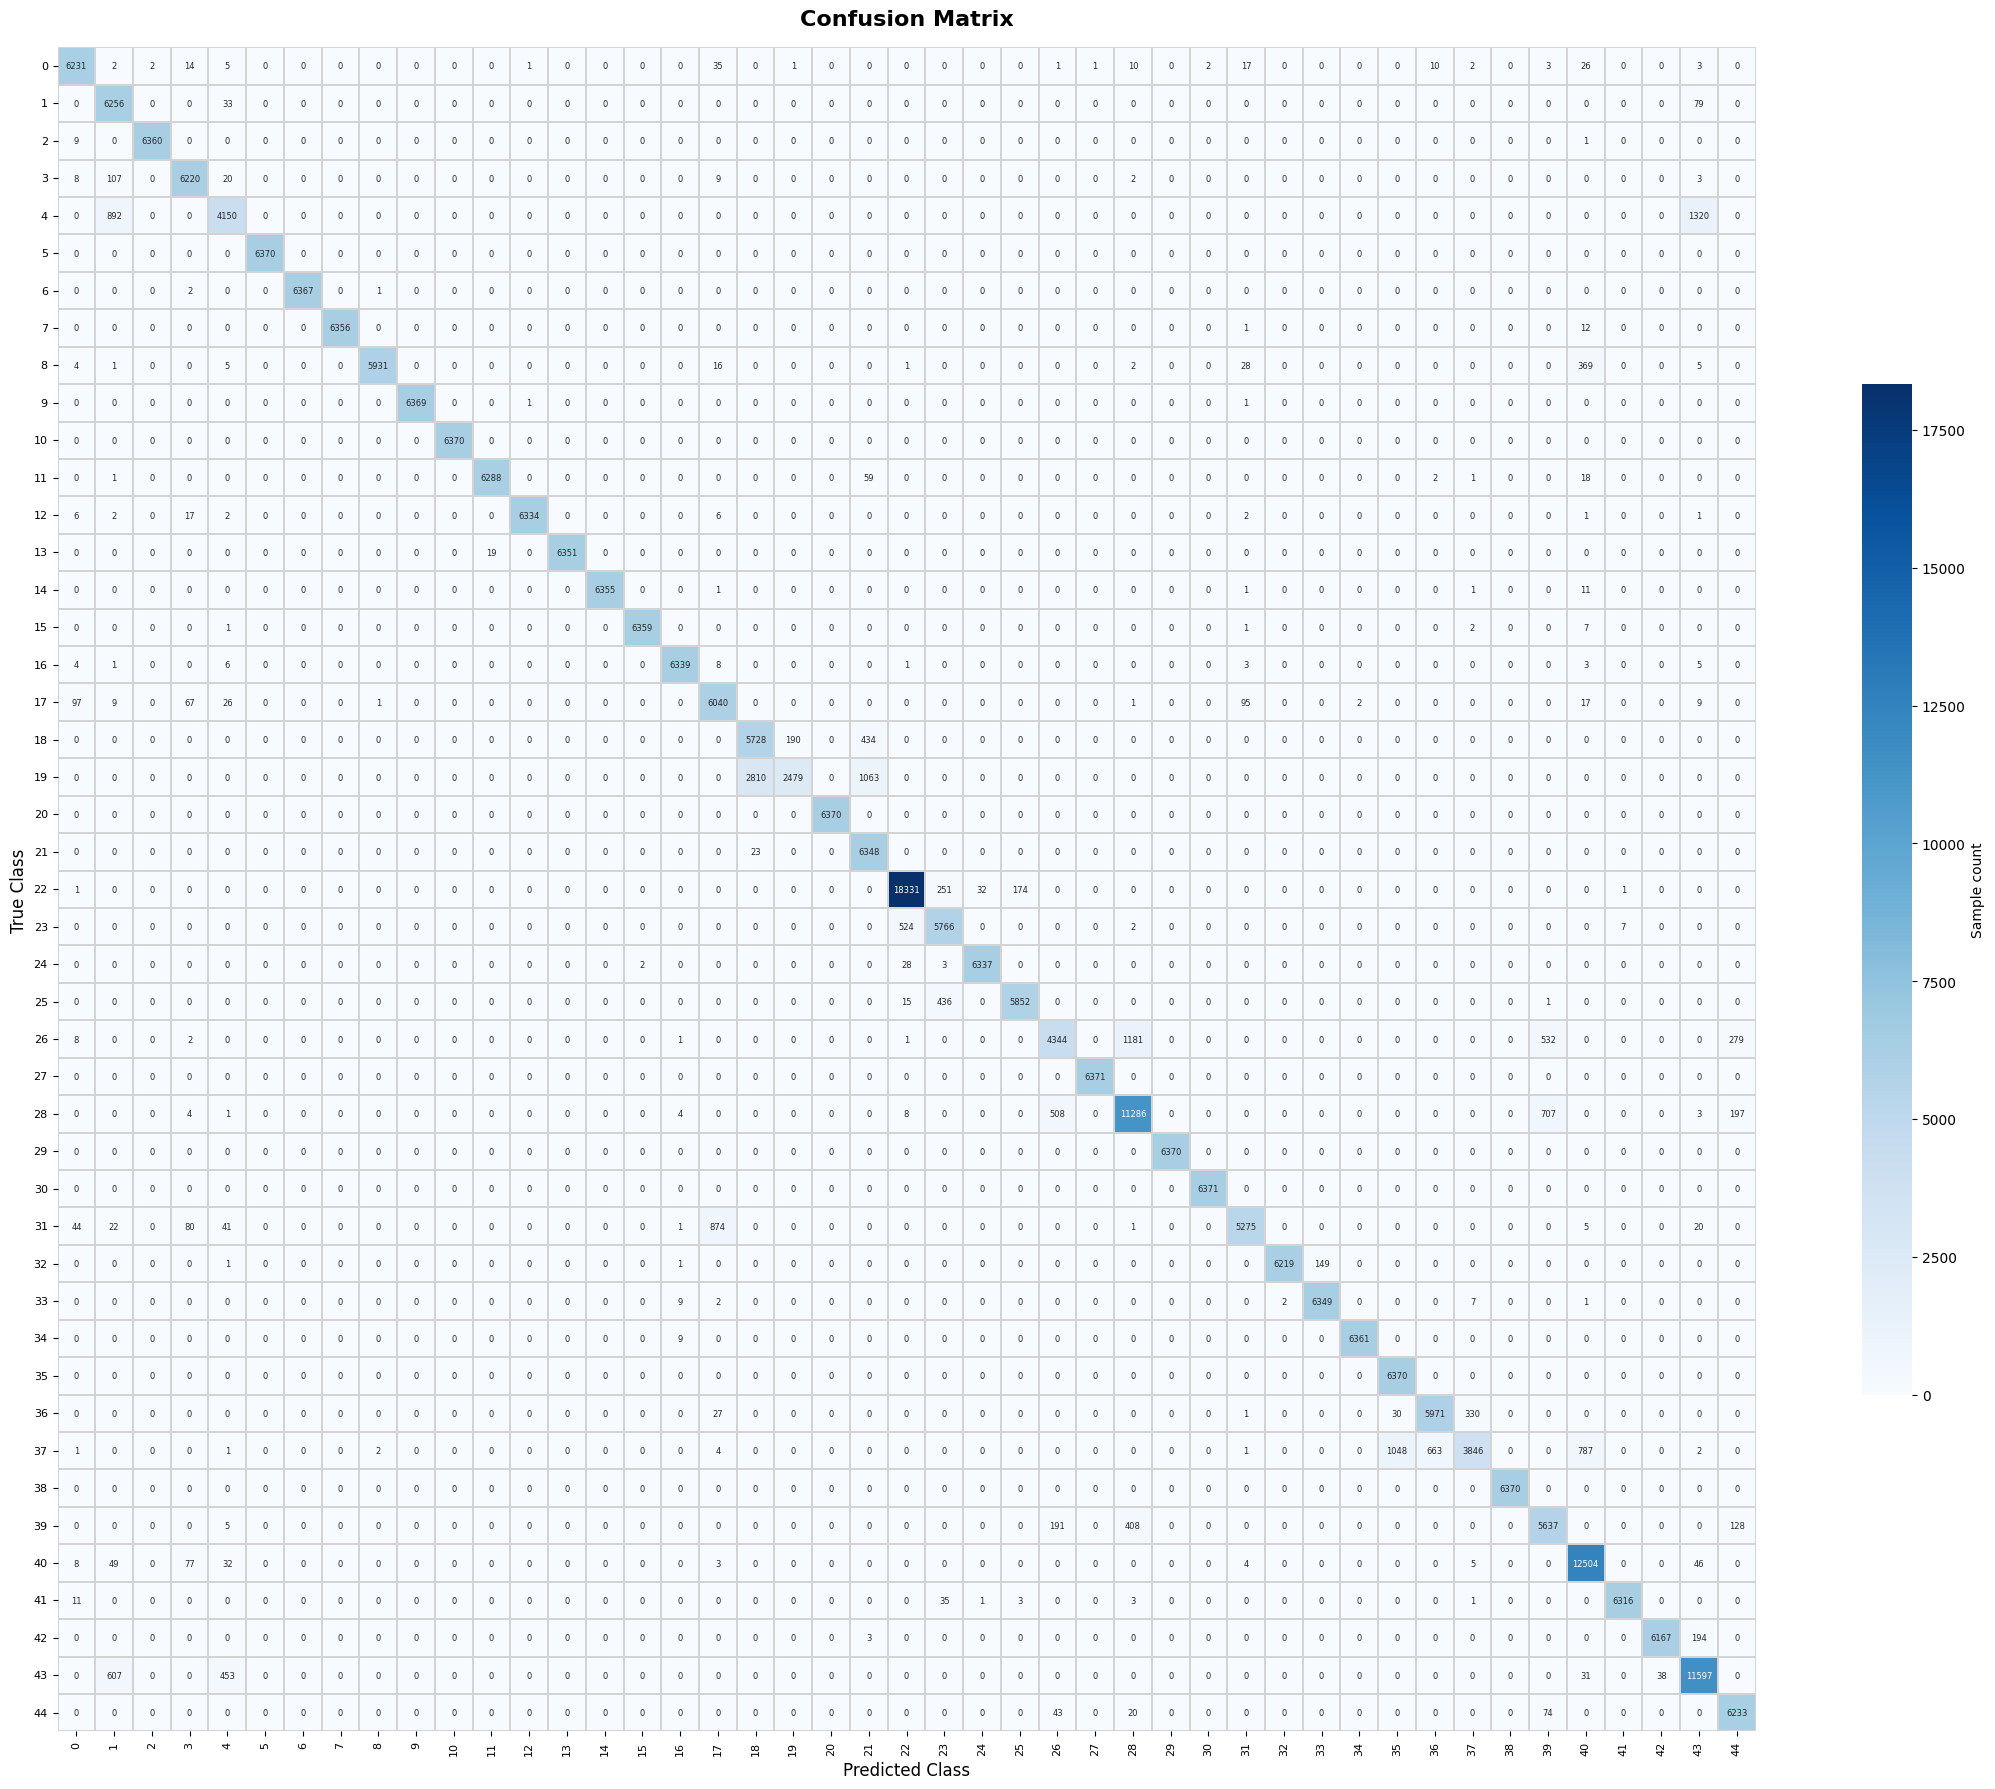

In [3]:
import joblib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Dataset
# =========================
class NumericDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# =========================
# Architectures
# =========================
class RoutingNet(nn.Module):
    def __init__(self, input_dim, num_experts):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Linear(input_dim, 256), nn.LayerNorm(256), nn.Dropout(0.1), nn.ReLU(),
            nn.Linear(256, 256), nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, 256), nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, 256), nn.LayerNorm(256), nn.ReLU(),
            nn.Linear(256, num_experts)
        )
    def forward(self, x): return self.sequential(x)

class Expert(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.LayerNorm(512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 128), nn.LayerNorm(128), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(128, 32), nn.LayerNorm(32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 32), nn.LayerNorm(32), nn.ReLU(),
            nn.Linear(32, 32), nn.LayerNorm(32), nn.ReLU(),
            nn.Linear(32, 16), nn.LayerNorm(16), nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.classifier = nn.Sequential(
            nn.Linear(8, 64), nn.LayerNorm(64), nn.ReLU(), nn.Dropout(0.01),
            nn.Linear(64, 128), nn.LayerNorm(128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.encoder(x))

# =========================
# Load Data
# =========================
x_res = joblib.load('X_res.pkl')
y_res = joblib.load('y_res.pkl')

merge_map = {23: 22, 27: 22, 46: 43, 49: 47, 31: 30}
y_res = y_res.replace(merge_map)
unique_classes = sorted(y_res.unique())
remap = {old: new for new, old in enumerate(unique_classes)}
y_res = y_res.map(remap)

x_res, _, y_res, _ = train_test_split(x_res, y_res, train_size=0.99, stratify=y_res, random_state=42)
_, X_val, _, y_val = train_test_split(x_res, y_res, test_size=0.2, stratify=y_res, random_state=42)

num_classes = y_val.nunique()
input_dim   = X_val.shape[1]
device      = "cuda" if torch.cuda.is_available() else "cpu"
n_experts   = 10  # match your training config

val_loader = DataLoader(NumericDataset(X_val, y_val), batch_size=256, shuffle=False)

# =========================
# Load Model
# =========================
Router_model = RoutingNet(input_dim, n_experts).to(device)
experts      = [Expert(input_dim, num_classes).to(device) for _ in range(n_experts)]

checkpoint = torch.load("models/best_model.pth", map_location=device)
Router_model.load_state_dict(checkpoint['router'])
for i, e in enumerate(experts):
    e.load_state_dict(checkpoint['experts'][i])

Router_model.eval()
for e in experts: e.eval()

# =========================
# Inference
# =========================
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        router_logits = Router_model(X_batch)
        router_probs  = torch.softmax(router_logits, dim=1)

        expert_outputs = torch.stack([torch.softmax(e(X_batch), dim=1) for e in experts])
        combined       = (router_probs.unsqueeze(2) * expert_outputs.permute(1, 0, 2)).sum(dim=1)
        final_preds    = torch.argmax(combined, dim=1)

        all_preds.extend(final_preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# =========================
# Confusion Matrix
# =========================
cm = confusion_matrix(all_labels, all_preds)

# Normalize by row (true labels) for readability
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    cm,
    ax=ax,
    cmap="Blues",
    linewidths=0.3,
    linecolor="lightgray",
    fmt="d",
    annot=True,
    annot_kws={"size": 6},
    cbar_kws={"shrink": 0.6, "label": "Sample count"}
)
ax.set_title("Confusion Matrix", fontsize=16, fontweight="bold", pad=16)
ax.set_xlabel("Predicted Class", fontsize=12)
ax.set_ylabel("True Class", fontsize=12)
ax.set_xticks(np.arange(num_classes) + 0.5)
ax.set_yticks(np.arange(num_classes) + 0.5)
ax.set_xticklabels([str(i) for i in range(num_classes)], rotation=90, fontsize=8)
ax.set_yticklabels([str(i) for i in range(num_classes)], rotation=0,  fontsize=8)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Visulise the hyperparameters

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

LOG_FILE = "grid_log.txt"

records = []
with open(LOG_FILE, "r") as f:
    for line in f:
        line = line.strip()
        if not line or "ERROR" in line or "Config:" not in line:
            continue
        try:
            parts  = line.split(" | ")
            f1     = float(parts[0].split(": ")[1])
            gap    = float(parts[1].split(": ")[1])
            config = json.loads(parts[2].split("Config: ")[1])
            records.append({"f1": f1, "gap": gap, **config})
        except:
            continue

print(f"Loaded {len(records)} records from {LOG_FILE}")

# Parameters to plot
params = ["n_experts", "lr_router", "lr_expert", "K", "spec_temp", "spec_weight", "div_weight", "momentum"]

ncols = 4
nrows = int(np.ceil(len(params) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, param in zip(axes, params):
    x = [r[param] for r in records]
    y = [r["f1"]   for r in records]

    jitter = (max(x) - min(x)) * 0.02 if max(x) != min(x) else 0.01
    x_jit  = [v + np.random.uniform(-jitter, jitter) for v in x]

    scatter = ax.scatter(x_jit, y, alpha=0.65, s=50, c=y, cmap="RdYlGn",
                         vmin=0, vmax=1, edgecolors="grey", linewidths=0.3)

    for v in sorted(set(x)):
        mean_f1 = np.mean([r["f1"] for r in records if r[param] == v])
        ax.hlines(mean_f1, v - jitter * 3, v + jitter * 3,
                  colors="steelblue", linewidths=2)

    ax.set_xlabel(param, fontsize=11)
    ax.set_ylabel("F1 Score", fontsize=10)
    ax.set_title(f"F1 vs {param}", fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.4)
    fig.colorbar(scatter, ax=ax, label="F1")

for ax in axes[len(params):]:
    ax.set_visible(False)

fig.suptitle("Hyperparameter vs F1 Score", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("hyperparam_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → hyperparam_scatter.png")